In [ ]:
from google.colab import files
import zipfile
import os

#загружаем архив
uploaded = files.upload()

#распаковка
zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

#смотрим структуру
!ls -la /content/dataset/


Saving project-4-at-2026-02-20-15-27-04ee68d0.zip to project-4-at-2026-02-20-15-27-04ee68d0.zip
total 40
drwxr-xr-x 4 root root  4096 Feb 20 13:29 .
drwxr-xr-x 1 root root  4096 Feb 20 13:29 ..
-rw-r--r-- 1 root root     6 Feb 20 13:29 classes.txt
drwxr-xr-x 2 root root 12288 Feb 20 13:29 images
drwxr-xr-x 2 root root 12288 Feb 20 13:29 labels
-rw-r--r-- 1 root root   176 Feb 20 13:29 notes.json


In [ ]:
#установка необходимых библиотек
!pip install ultralytics
!pip install roboflow
!pip install albumentations

import ultralytics
ultralytics.checks()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.9/112.6 GB disk)


In [ ]:
%%writefile /content/dataset.yaml

#пути к данным
path: /content/dataset  #корневая папка датасета
train: images  #папка с тренировочными изображениями
val: images    #папка с валидационными (на всякий случай)

#количество классов
nc: 1

#названия классов
names: ['tail']

Writing /content/dataset.yaml


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

#создаем структуру папок
os.makedirs('/content/dataset/train/images', exist_ok=True)
os.makedirs('/content/dataset/train/labels', exist_ok=True)
os.makedirs('/content/dataset/val/images', exist_ok=True)
os.makedirs('/content/dataset/val/labels', exist_ok=True)

#получаем список всех изображений
images = [f for f in os.listdir('/content/dataset/images')
          if f.endswith(('.jpg', '.jpeg', '.png'))]

#разделяем на train и val
train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

print(f"Train: {len(train_images)} images")
print(f"Val: {len(val_images)} images")

#копируем файлы в соответствующие папки
for img in train_images:
    #копируем изображение
    shutil.copy(f'/content/dataset/images/{img}', f'/content/dataset/train/images/{img}')
    #копируем соответствующий .txt файл
    txt_file = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'/content/dataset/labels/{txt_file}'):
        shutil.copy(f'/content/dataset/labels/{txt_file}', f'/content/dataset/train/labels/{txt_file}')

for img in val_images:
    shutil.copy(f'/content/dataset/images/{img}', f'/content/dataset/val/images/{img}')
    txt_file = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'/content/dataset/labels/{txt_file}'):
        shutil.copy(f'/content/dataset/labels/{txt_file}', f'/content/dataset/val/labels/{txt_file}')

Train: 51 images
Val: 13 images


In [ ]:
%%writefile /content/dataset.yaml

path: /content/dataset
train: train/images  #теперь указываем подпапки
val: val/images
nc: 1
names: ['tail']

Overwriting /content/dataset.yaml


In [ ]:
import cv2
import numpy as np
import albumentations as A
import random
import os
from pathlib import Path
import matplotlib.pyplot as plt

def generate_synthetic_tails(
    source_images_dir,  #папка с исходными фото
    source_labels_dir,  #папка с разметкой
    backgrounds_dir,    #папка с фонами
    output_dir,         #куда сохранять
    num_synthetic=100   #сколько генерировать
):
    """
    Генерирует синтетические данные - хвосты на случайных фонах
    """
    os.makedirs(f"{output_dir}/images", exist_ok=True)
    os.makedirs(f"{output_dir}/labels", exist_ok=True)

    #загружаем все исходные хвосты
    source_images = list(Path(source_images_dir).glob('*.jpg')) + list(Path(source_images_dir).glob('*.png'))
    print(f"Найдено исходных изображений: {len(source_images)}")

    #загружаем фоны
    backgrounds = list(Path(backgrounds_dir).glob('*.jpg')) + list(Path(backgrounds_dir).glob('*.png'))
    print(f"Найдено фонов: {len(backgrounds)}")

    if not backgrounds:
        print("Нет фонов")
        return

    #аугментации для хвоста перед вставкой
    tail_transform = A.Compose([
        A.Rotate(limit=45, p=0.8),           #поворот
        A.RandomScale(scale_limit=0.3, p=0.7), #масштаб
        A.RandomBrightnessContrast(p=0.5),    #яркость/контраст
        A.HueSaturationValue(p=0.3),          #цвет
        A.Blur(blur_limit=3, p=0.2),           #размытие
    ])

    for i in range(num_synthetic):
        #выбираем случайный исходный хвост
        src_path = random.choice(source_images)
        src_img = cv2.imread(str(src_path))
        src_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB)
        h_src, w_src = src_img.shape[:2]

        #загружаем разметку для этого хвоста
        label_path = Path(source_labels_dir) / (src_path.stem + '.txt')
        if not label_path.exists():
            continue

        with open(label_path, 'r') as f:
            line = f.readline().strip()
            parts = line.split()
            class_id = parts[0]
            coords = list(map(float, parts[1:]))

        #создаем маску хвоста
        mask = np.zeros((h_src, w_src), dtype=np.uint8)
        points = []
        for j in range(0, len(coords), 2):
            x = int(coords[j] * w_src)
            y = int(coords[j+1] * h_src)
            points.append([x, y])
        points = np.array(points, dtype=np.int32)
        cv2.fillPoly(mask, [points], 255)

        #извлекаем только хвост с его маской
        tail_only = cv2.bitwise_and(src_img, src_img, mask=mask)

        #выбираем случайный фон
        bg_path = random.choice(backgrounds)
        bg = cv2.imread(str(bg_path))
        bg = cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)
        bg = cv2.resize(bg, (640, 640))  #фиксируем размер

        #применяем аугментации к хвосту
        augmented = tail_transform(image=tail_only, mask=mask)
        tail_aug = augmented['image']
        mask_aug = augmented['mask']

        #находим контур хвоста после аугментаций
        contours, _ = cv2.findContours(mask_aug, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        #берем самый большой контур
        tail_contour = max(contours, key=cv2.contourArea)

        #определяем позицию вставки (случайно)
        h_tail, w_tail = tail_aug.shape[:2]
        max_x = bg.shape[1] - w_tail
        max_y = bg.shape[0] - h_tail

        if max_x < 10 or max_y < 10:
            continue

        pos_x = random.randint(10, max_x)
        pos_y = random.randint(10, max_y)

        #вставляем хвост на фон
        result = bg.copy()
        roi = result[pos_y:pos_y+h_tail, pos_x:pos_x+w_tail]

        #создаем маску для наложения
        mask_3channel = cv2.cvtColor(mask_aug, cv2.COLOR_GRAY2BGR) / 255.0

        #наложение
        blended = (roi * (1 - mask_3channel) + tail_aug * mask_3channel).astype(np.uint8)
        result[pos_y:pos_y+h_tail, pos_x:pos_x+w_tail] = blended

        #создаем новую разметку для синтетического изображения
        new_coords = []
        for point in tail_contour:
            x_point, y_point = point[0]
            #глобальные координаты на фоне
            global_x = (pos_x + x_point) / bg.shape[1]
            global_y = (pos_y + y_point) / bg.shape[0]
            new_coords.extend([global_x, global_y])

        #сохраняем
        out_img_path = f"{output_dir}/images/synth_{i:04d}.jpg"
        out_label_path = f"{output_dir}/labels/synth_{i:04d}.txt"

        cv2.imwrite(out_img_path, cv2.cvtColor(result, cv2.COLOR_RGB2BGR))

        with open(out_label_path, 'w') as f:
            line = f"{class_id} " + " ".join([f"{c:.6f}" for c in new_coords])
            f.write(line)

        if i % 10 == 0:
            print(f"Сгенерировано {i}/{num_synthetic}")

    print(f" Сгенерировано {num_synthetic} синтетических изображений")

#использование:
generate_synthetic_tails(
    source_images_dir="/content/dataset/images",
    source_labels_dir="/content/dataset/labels",
    backgrounds_dir="/path/to/backgrounds",  #нужно создать папку с фонами
    output_dir="/content/dataset_synthetic",
    num_synthetic=100
)

Найдено исходных изображений: 64
Найдено фонов: 0
Нет фонов


In [ ]:
#скачиваем COCO-128, которые можно использовать как фоны
!wget -O /content/coco128.zip https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
!unzip /content/coco128.zip -d /content/backgrounds_coco/

--2026-02-20 13:30:17--  https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/854f8531-cc3e-47d1-9f20-5d8fa189e18a?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-20T14%3A19%3A08Z&rscd=attachment%3B+filename%3Dcoco128.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-20T13%3A18%3A35Z&ske=2026-02-20T14%3A19%3A08Z&sks=b&skv=2018-11-09&sig=At0djDc6BZuj0dT%2FnQO3KiAPQR7Fs9tecuigAcAbm2s%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MTU5NDUxNywibmJmIjoxNzcxNTk0MjE3LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

In [ ]:
import os
import zipfile
from pathlib import Path

#путь к скачанному архиву
zip_path = "/content/coco128.zip"
#папка для распаковки
extract_path = "/content/backgrounds_coco"

#создаем папку, если её нет
os.makedirs(extract_path, exist_ok=True)

#распаковываем архив
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Архив распакован в {extract_path}")

Архив распакован в /content/backgrounds_coco


In [ ]:
backgrounds_dir = "/content/backgrounds_coco/coco128/images/train2017/"

#проверяем, существует ли папка
if os.path.exists(backgrounds_dir):
    bg_files = os.listdir(backgrounds_dir)
    print(f"Найдено фонов в {backgrounds_dir}: {len(bg_files)}")
    print(f"Примеры: {bg_files[:5]}")
else:
    #если структура другая, ищем все .jpg файлы рекурсивно
    bg_files = list(Path("/content/backgrounds_coco").rglob("*.jpg"))
    print(f"Найдено .jpg файлов всего: {len(bg_files)}")
    if bg_files:
        backgrounds_dir = str(bg_files[0].parent)
        print(f"Фоны находятся в: {backgrounds_dir}")

Найдено фонов в /content/backgrounds_coco/coco128/images/train2017/: 128
Примеры: ['000000000071.jpg', '000000000531.jpg', '000000000294.jpg', '000000000036.jpg', '000000000544.jpg']


In [ ]:
#создаем простую структуру- это одна папка со всеми фонами
!mkdir -p /content/backgrounds

#копируем все изображения в одну папку
if 'bg_files' in locals() and bg_files:
    for i, bg_file in enumerate(bg_files):
        !cp "{bg_file}" /content/backgrounds/
    print(f"Скопировано {len(bg_files)} фонов в /content/backgrounds/")
else:
    print("Нет файлов")
    !find /content/backgrounds_coco -type f -name "*.jpg" | head -10

cp: cannot stat '000000000071.jpg': No such file or directory
cp: cannot stat '000000000531.jpg': No such file or directory
cp: cannot stat '000000000294.jpg': No such file or directory
cp: cannot stat '000000000036.jpg': No such file or directory
cp: cannot stat '000000000544.jpg': No such file or directory
cp: cannot stat '000000000092.jpg': No such file or directory
cp: cannot stat '000000000459.jpg': No such file or directory
cp: cannot stat '000000000389.jpg': No such file or directory
cp: cannot stat '000000000575.jpg': No such file or directory
cp: cannot stat '000000000081.jpg': No such file or directory
cp: cannot stat '000000000572.jpg': No such file or directory
cp: cannot stat '000000000605.jpg': No such file or directory
cp: cannot stat '000000000395.jpg': No such file or directory
cp: cannot stat '000000000201.jpg': No such file or directory
cp: cannot stat '000000000154.jpg': No such file or directory
cp: cannot stat '000000000514.jpg': No such file or directory
cp: cann

In [ ]:
generate_synthetic_tails(
    source_images_dir="/content/dataset/images",
    source_labels_dir="/content/dataset/labels",
    backgrounds_dir="/content/backgrounds_coco/coco128/images/train2017",  #папка со всеми фонами
    output_dir="/content/dataset_synthetic",
    num_synthetic=100  #сколько генерировать
)

Найдено исходных изображений: 64
Найдено фонов: 128
Сгенерировано 0/100
Сгенерировано 10/100
Сгенерировано 20/100
Сгенерировано 30/100
Сгенерировано 40/100
Сгенерировано 50/100
Сгенерировано 60/100
Сгенерировано 70/100
Сгенерировано 80/100
Сгенерировано 90/100
 Сгенерировано 100 синтетических изображений


In [ ]:
import os
import shutil

#создаем папку для финального датасета
!mkdir -p /content/final_dataset/images
!mkdir -p /content/final_dataset/labels

#копируем реальные данные
!cp /content/dataset/train/images/* /content/final_dataset/images/ 2>/dev/null
!cp /content/dataset/train/labels/* /content/final_dataset/labels/ 2>/dev/null

#копируем валидационные данные
!cp /content/dataset/val/images/* /content/final_dataset/images/ 2>/dev/null
!cp /content/dataset/val/labels/* /content/final_dataset/labels/ 2>/dev/null

#копируем синтетические данные
!cp /content/dataset_synthetic/images/* /content/final_dataset/images/
!cp /content/dataset_synthetic/labels/* /content/final_dataset/labels/

print(f"Всего изображений в финальном датасете: {len(os.listdir('/content/final_dataset/images'))}")
print(f"Всего файлов разметки: {len(os.listdir('/content/final_dataset/labels'))}")

Всего изображений в финальном датасете: 164
Всего файлов разметки: 164


In [ ]:
%%writefile /content/dataset_updated.yaml

#пути к данным
path: /content/final_dataset  #корневая папка с объединенными данными
train: images  #все изображения в одной папке
val: images    #пока валидация там же
#количество классов
nc: 1

#названия классов
names: ['tail']

Writing /content/dataset_updated.yaml


In [ ]:
from sklearn.model_selection import train_test_split
import os
import shutil

#создаем структуру
!mkdir -p /content/final_split/train/images
!mkdir -p /content/final_split/train/labels
!mkdir -p /content/final_split/val/images
!mkdir -p /content/final_split/val/labels

#получаем все изображения
all_images = os.listdir('/content/final_dataset/images')

#отделяем реальные от синтетических
real_images = [f for f in all_images if not f.startswith('synth_')]
synthetic_images = [f for f in all_images if f.startswith('synth_')]

print(f"Реальных: {len(real_images)}")
print(f"Синтетических: {len(synthetic_images)}")

#разделение реальных 80 на 20 %
real_train, real_val = train_test_split(real_images, test_size=0.2, random_state=42)

#синтетические все идут в train
synth_train = synthetic_images

#объединяем
train_images = real_train + synth_train
val_images = real_val

print(f"Train: {len(train_images)} изображений")
print(f"Val: {len(val_images)} изображений")

#копируем train
for img in train_images:
    #копируем изображение
    shutil.copy(f'/content/final_dataset/images/{img}', f'/content/final_split/train/images/{img}')
    #копируем соответствующий .txt
    txt_file = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'/content/final_dataset/labels/{txt_file}'):
        shutil.copy(f'/content/final_dataset/labels/{txt_file}', f'/content/final_split/train/labels/{txt_file}')

#копируем val
for img in val_images:
    shutil.copy(f'/content/final_dataset/images/{img}', f'/content/final_split/val/images/{img}')
    txt_file = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'/content/final_dataset/labels/{txt_file}'):
        shutil.copy(f'/content/final_dataset/labels/{txt_file}', f'/content/final_split/val/labels/{txt_file}')

print("Данные разделены!")

Реальных: 64
Синтетических: 100
Train: 151 изображений
Val: 13 изображений
Данные разделены!


In [ ]:
%%writefile /content/dataset_final.yaml

path: /content/final_split
train: train/images
val: val/images
nc: 1
names: ['tail']

Writing /content/dataset_final.yaml


In [ ]:
from google.colab import drive
import os

#монтируем Google Drive
drive.mount('/content/drive')

#создаем папку для проектов
!mkdir -p /content/drive/MyDrive/yolo_projects/tail_segmentation




Mounted at /content/drive


In [ ]:

from ultralytics import YOLO

#загружаем предобученную модель
model = YOLO('yolo11n-seg.pt')

#обучаем с параметрами аугментаций
results = model.train(
    data='/content/dataset_final.yaml',
    epochs=100,
    imgsz=640,
    batch=8,
    workers=4,
    patience=20,
    save=True,
    device='cuda',

    #включаем аугментации
    augment=True,


    degrees=30.0,        #поворот до 30 градусов
    translate=0.2,        #сдвиг до 20% от размера изображения
    scale=0.5,           #масштаб изменение размера объекта на 50%
    shear=10.0,          #сдвиг до 10 градусов
    perspective=0.0002,  #перспектива


    hsv_h=0.1,           #изменение оттенка
    hsv_s=0.7,           #изменение насыщенности, стандартное значение 0.7
    hsv_v=0.5,           #изменение яркости, стандартное значение 0.5


    mosaic=1.0,          #склейка 4 изображений в одно
    mixup=0.3,           #смешивание двух изображений
    copy_paste=0.4,      #копирование сегментов  на другие фото
    fliplr=0.5,          #горизонтальное отражение
    flipud=0.1,          #вертикальное отражение
)

#копируем лучшую модель на гугл диск
import shutil
import os

#создаем имя файла с датой, чтобы не перезаписывать
from datetime import datetime
date_str = datetime.now().strftime("%Y%m%d_%H%M")
model_name = f'tail_model_{date_str}.pt'

#копируем
source_path = '/content/runs/segment/train/weights/best.pt'
dest_path = f'/content/drive/MyDrive/yolo_projects/tail_segmentation/{model_name}'

if os.path.exists(source_path):
    shutil.copy(source_path, dest_path)
    print(f"Модель сохранена в Google Drive как: {model_name}")
    print(f"mAP50-95: {results.box.map:.4f}")
else:
    print("Файл best.pt не найден. Проверьте путь.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_final.yaml, degrees=30.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.1, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0

In [ ]:
#визуализация метрик
from IPython.display import Image
Image(filename='/content/runs/segment/train/results.png')

#метрики на валидационной выборке
metrics = model.val()
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1048.9±469.6 MB/s, size: 31.7 KB)
val: Scanning /content/final_split/val/labels.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 3.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all         13         13      0.377      0.615      0.519      0.332      0.685      0.462      0.555      0.273
Speed: 1.9ms preprocess, 16.4ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /content/runs/segment/val
mAP50-95: 0.3318


In [ ]:
from google.colab import files
import os

#путь к лучшей модели
model_path = '/content/drive/MyDrive/yolo_projects/tail_segmentation/tail_model_20260220_1348.pt'

#скачиваем
files.download(model_path)

print("Модель скачана на компьютер!")
print("Файл: tail_model_20260220_1348.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Модель скачана на компьютер!
Файл: tail_model_20260220_1348.pt


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/yolo_projects/tail_segmentation/tail_model_20260220_1348.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Проверяем модель: /content/drive/MyDrive/yolo_projects/tail_segmentation/tail_model_20260220_1348.pt - есть!
Фото найдено: /content/drive/MyDrive/yolo_projects/tail_segmentation/new_cat.jpg
Загружаем модель...
Предсказываем...

image 1/1 /content/drive/MyDrive/yolo_projects/tail_segmentation/new_cat.jpg: 448x640 1 tail, 9.9ms
Speed: 1.7ms preprocess, 9.9ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)


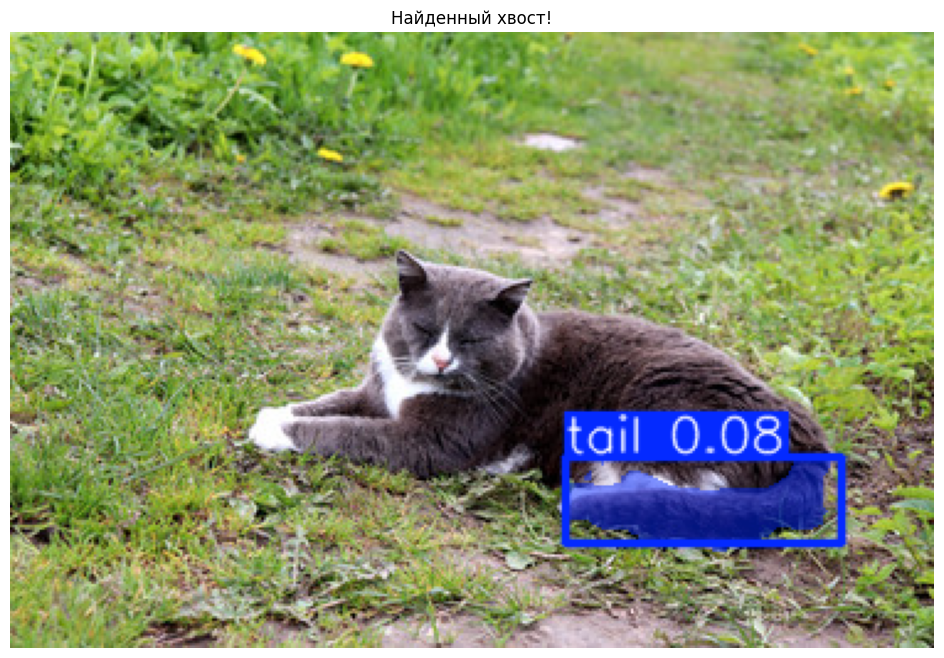

Результат сохранен: /content/drive/MyDrive/yolo_projects/tail_segmentation/new_cat_result.jpg


In [ ]:
from google.colab import drive
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

#монтируем
drive.mount('/content/drive')

#путь к папке с фото
folder_path = "/content/drive/MyDrive/yolo_projects/tail_segmentation"

#путь к модели
model_path = f"{folder_path}/tail_model_20260220_1348.pt"

#путь к новому фото

image_path = f"{folder_path}/new_cat.jpg"  # если .jpg
#image_path = f"{folder_path}/new_cat.png"  # если .png

#проверяем, что файлы существуют
print(f"Проверяем модель: {model_path} - {'есть!' if os.path.exists(model_path) else 'нет'}")

#ищем фото
if not os.path.exists(image_path):
    #пробуем разные расширения
    for ext in ['.jpg', '.jpeg', '.png']:
        test_path = f"{folder_path}/new_cat{ext}"
        if os.path.exists(test_path):
            image_path = test_path
            print(f"Найдено фото: {image_path}")
            break

if not os.path.exists(image_path):
    print(f"Файл new_cat с расширениями .jpg/.jpeg/.png не найден в {folder_path}")
    print("Содержимое папки:")
    !ls -la "{folder_path}"
else:
    print(f"Фото найдено: {image_path}")

    #загружаем модель
    print("Загружаем модель...")
    model = YOLO(model_path)

    #делаем предсказание
    print("Предсказываем...")
    results = model(image_path, conf=0.05)

    #визуализация
    result_image = results[0].plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Найденный хвост!")
    plt.show()

    #сохраняем результат рядом с оригиналом
    output_path = f"{folder_path}/new_cat_result.jpg"
    cv2.imwrite(output_path, result_image)
    print(f"Результат сохранен: {output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Порог уверенности: 0.25 ---

image 1/1 /content/drive/MyDrive/yolo_projects/tail_segmentation/new_cat_3.jpg: 448x640 2 tails, 9.9ms
Speed: 2.1ms preprocess, 9.9ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
  Объект 1: уверенность 0.445
  Объект 2: уверенность 0.288

--- Порог уверенности: 0.1 ---

image 1/1 /content/drive/MyDrive/yolo_projects/tail_segmentation/new_cat_3.jpg: 448x640 3 tails, 18.4ms
Speed: 5.0ms preprocess, 18.4ms inference, 3.4ms postprocess per image at shape (1, 3, 448, 640)
  Объект 1: уверенность 0.445
  Объект 2: уверенность 0.288
  Объект 3: уверенность 0.139

--- Порог уверенности: 0.05 ---

image 1/1 /content/drive/MyDrive/yolo_projects/tail_segmentation/new_cat_3.jpg: 448x640 5 tails, 18.6ms
Speed: 3.1ms preprocess, 18.6ms inference, 3.3ms postprocess per image at shape (1, 3, 448, 640)
  Объект 1: уверенн

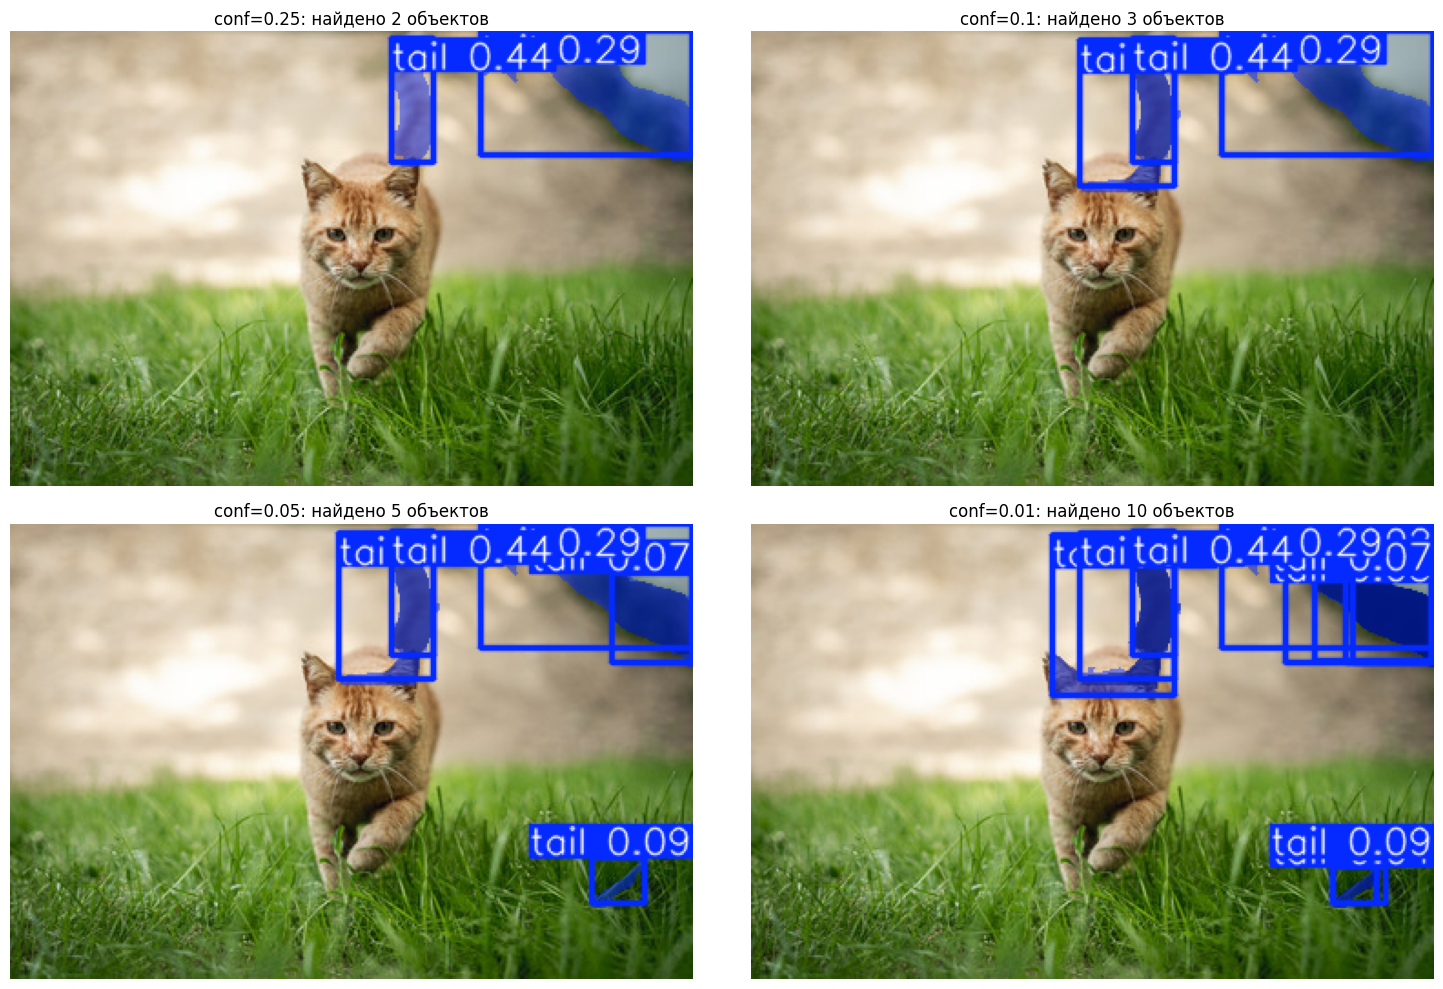

In [ ]:
#тесты разных порогов уверенности, чтобф понять как дальше обучать модель
from google.colab import drive
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os
import numpy as np

#монтируем диск
drive.mount('/content/drive')

#пути
folder_path = "/content/drive/MyDrive/yolo_projects/tail_segmentation"
model_path = f"{folder_path}/tail_model_20260220_1348.pt"
image_path = f"{folder_path}/new_cat_3.jpg"

#загружаем модель
model = YOLO(model_path)

#пробуем разные пороги уверенности
thresholds = [0.25, 0.1, 0.05, 0.01]

plt.figure(figsize=(15, 10))

for i, conf_thresh in enumerate(thresholds):
    print(f"\n--- Порог уверенности: {conf_thresh} ---")
    results = model(image_path, conf=conf_thresh)

    #показываем результат
    plt.subplot(2, 2, i+1)

    if len(results[0].boxes) > 0:
        result_img = results[0].plot()
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title(f"conf={conf_thresh}: найдено {len(results[0].boxes)} объектов")

        #выводим информацию о найденных объектах
        for j, box in enumerate(results[0].boxes):
            conf = box.conf[0].item()
            print(f"  Объект {j+1}: уверенность {conf:.3f}")
    else:
        #показываем оригинал
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title(f"conf={conf_thresh}: ничего не найдено")
        print("Ничего не найдено")

    plt.axis('off')

plt.tight_layout()
plt.show()